# ClinVar EDA

Raw parquet from `python src/ingest_clinvar.py`.


In [1]:
from pathlib import Path
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

In [2]:

load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
CLINVAR_PARQUET = project_root / "data/raw/clinvar_reliable_grch38.parquet"
CLINVAR_CLEAN = project_root / "data/processed/clinvar_clean.parquet"
CLINVAR_CLEAN_VUS = project_root / "data/processed/clinvar_clean_vus.parquet"

In [3]:
df = pd.read_parquet(CLINVAR_PARQUET)
df.shape


(21978, 18)

In [4]:
df.columns

Index(['Type', 'Name', 'GeneSymbol', 'HGNC_ID', 'ClinicalSignificance',
       'LastEvaluated', 'PhenotypeIDS', 'PhenotypeList', 'OriginSimple',
       'Assembly', 'Chromosome', 'Start', 'Stop', 'ReviewStatus',
       'NumberSubmitters', 'VariationID', 'ReferenceAlleleVCF',
       'AlternateAlleleVCF'],
      dtype='object')

In [5]:
df.head(1)


,Type,Name,GeneSymbol,HGNC_ID,ClinicalSignificance,LastEvaluated,PhenotypeIDS,PhenotypeList,OriginSimple,Assembly,Chromosome,Start,Stop,ReviewStatus,NumberSubmitters,VariationID,ReferenceAlleleVCF,AlternateAlleleVCF
0,single nucleotide variant,NM_000552.5(VWF):c.4883T>C (p.Ile1628Thr),VWF,HGNC:12726,Pathogenic,"Aug 13, 2024","MONDO:MONDO:0015628,MedGen:C1282968,Orphanet:1...",Von Willebrand disease type 2A|not provided|He...,germline,GRCh38,12,6018535,6018535,reviewed by expert panel,16,284,A,G


In [6]:
df[df['VariationID']==54970]

,Type,Name,GeneSymbol,HGNC_ID,ClinicalSignificance,LastEvaluated,PhenotypeIDS,PhenotypeList,OriginSimple,Assembly,Chromosome,Start,Stop,ReviewStatus,NumberSubmitters,VariationID,ReferenceAlleleVCF,AlternateAlleleVCF
3998,single nucleotide variant,NM_007294.4(BRCA1):c.3708T>G (p.Asn1236Lys),BRCA1,HGNC:1100,Benign,"Jun 18, 2019","MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777...",Hereditary breast ovarian cancer syndrome|Brea...,germline,GRCh38,17,43091823,43091823,reviewed by expert panel,37,54970,A,C


In [7]:
df['Type'].value_counts(dropna=False).head(20)


Type
single nucleotide variant    15402
Deletion                      3856
Duplication                   1423
Microsatellite                 519
Insertion                      476
Indel                          294
Inversion                        7
Variation                        1
Name: count, dtype: int64

In [8]:
df['ReferenceAlleleVCF'].value_counts(dropna=False).head(20)  
# df['AlternateAlleleVCF'].value_counts(dropna=False).head(20)  


ReferenceAlleleVCF
G      5529
C      5454
T      3265
A      3164
CT      248
CA      235
GA      219
AG      204
AT      204
TC      202
TG      198
AC      188
GC      148
TA      138
GT      131
na       94
CTG      71
CG       64
CAG      63
CTT      62
Name: count, dtype: Int64

In [9]:
df['ReviewStatus'].value_counts(dropna=False)


ReviewStatus
reviewed by expert panel    21924
practice guideline             54
Name: count, dtype: int64

In [10]:
df['ClinicalSignificance'].value_counts(dropna=False)


ClinicalSignificance
Pathogenic                                                     9600
Uncertain significance                                         3866
Likely pathogenic                                              2801
Benign                                                         2775
Likely benign                                                  2766
drug response                                                   106
Pathogenic; drug response                                        38
Likely pathogenic; drug response                                 11
Uncertain significance; drug response                             3
Pathogenic/Likely pathogenic                                      3
Pathogenic/Likely pathogenic; drug response                       2
Conflicting classifications of pathogenicity                      2
Conflicting classifications of pathogenicity; drug response       1
other                                                             1
not provided               

In [11]:
df['PhenotypeList'].value_counts(dropna=False).head(20)


PhenotypeList
Breast-ovarian cancer, familial, susceptibility to, 2                                                                                                                                                    1115
Breast-ovarian cancer, familial, susceptibility to, 1                                                                                                                                                    1104
Hereditary thrombocytopenia and hematological cancer predisposition syndrome associated with RUNX1|Hereditary thrombocytopenia and hematologic cancer predisposition syndrome                             688
Monogenic diabetes                                                                                                                                                                                        428
Lynch syndrome                                                                                                                                                    

In [12]:
df_tmp = df[
    df["PhenotypeList"].isna() | (df["PhenotypeList"] == "not provided") | (df["PhenotypeList"] == "not specified")
]
df_tmp['ClinicalSignificance'].value_counts(dropna=False)


Series([], Name: count, dtype: int64)

In [13]:
df_tmp = df[df["ClinicalSignificance"] == "Uncertain significance"]
df_tmp['PhenotypeList'].value_counts(dropna=False)


PhenotypeList
Hereditary thrombocytopenia and hematological cancer predisposition syndrome associated with RUNX1|Hereditary thrombocytopenia and hematologic cancer predisposition syndrome                               352
Monogenic diabetes                                                                                                                                                                                          171
Hereditary thrombocytopenia and hematological cancer predisposition syndrome associated with RUNX1|Hereditary thrombocytopenia and hematologic cancer predisposition syndrome|Inborn genetic diseases       154
Open-angle glaucoma                                                                                                                                                                                         130
Phenylketonuria                                                                                                                                           

In [14]:
df_clean = pd.read_parquet(project_root / "data/processed/clinvar_clean.parquet")

In [15]:

print("variants:", len(df_clean), "| genes:", df_clean["GeneSymbol"].astype(str).nunique())
print("assembly:", sorted(df_clean["Assembly"].astype(str).unique()))
print("variant types:", sorted(df_clean["Type"].astype(str).unique()))
print("chromosomes:", sorted(df_clean["Chromosome"].astype(str).unique()))
print("\nreview status:")
print(df_clean["ReviewStatus"].value_counts())
print("\nclinical significance:")
print(df_clean["ClinicalSignificance"].value_counts())

variants: 11635 | genes: 177
assembly: ['GRCh38']
variant types: ['single nucleotide variant']
chromosomes: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '9', 'MT', 'X']

review status:
ReviewStatus
reviewed by expert panel    11616
practice guideline             19
Name: count, dtype: int64

clinical significance:
ClinicalSignificance
Pathogenic                      4092
Likely benign                   2705
Benign                          2516
Likely pathogenic               2318
Pathogenic/Likely pathogenic       3
Benign/Likely benign               1
Name: count, dtype: int64


In [16]:

cov = pd.Series({f: df_clean[f].notna().mean() for f in df_clean.columns})
(cov.sort_values(ascending=False) * 100).round(0).astype(int).rename("non_null_%")

Type                    100
Name                    100
GeneSymbol              100
HGNC_ID                 100
ClinicalSignificance    100
LastEvaluated           100
PhenotypeIDS            100
PhenotypeList           100
OriginSimple            100
Assembly                100
Chromosome              100
Start                   100
Stop                    100
ReviewStatus            100
NumberSubmitters        100
VariationID             100
ReferenceAlleleVCF      100
AlternateAlleleVCF      100
label                   100
Name: non_null_%, dtype: int64

## Clinical significance in the raw ingest

Expert-reviewed GRCh38 rows before the SNV / P-vs-B clean. VUS are already in this file; `clean_clinvar.py` splits them out so they never become training labels.


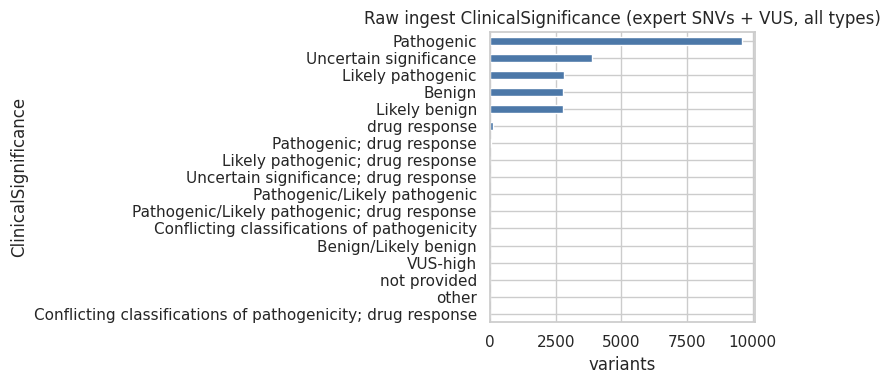

In [17]:
sig = df["ClinicalSignificance"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sig.sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_xlabel("variants")
ax.set_title("Raw ingest ClinicalSignificance (expert SNVs + VUS, all types)")
plt.tight_layout()
plt.show()


## Cleaned P/B vs VUS

`clinvar_clean.parquet` is pathogenic/benign SNVs used for training. `clinvar_clean_vus.parquet` is the same QC, `label=vus`, held out for inference.


labelled (11635, 19) {'pathogenic': 6413, 'benign': 5222}
VUS      (3606, 19) genes 154
labelled genes 177
gene overlap P/B ∩ VUS 143


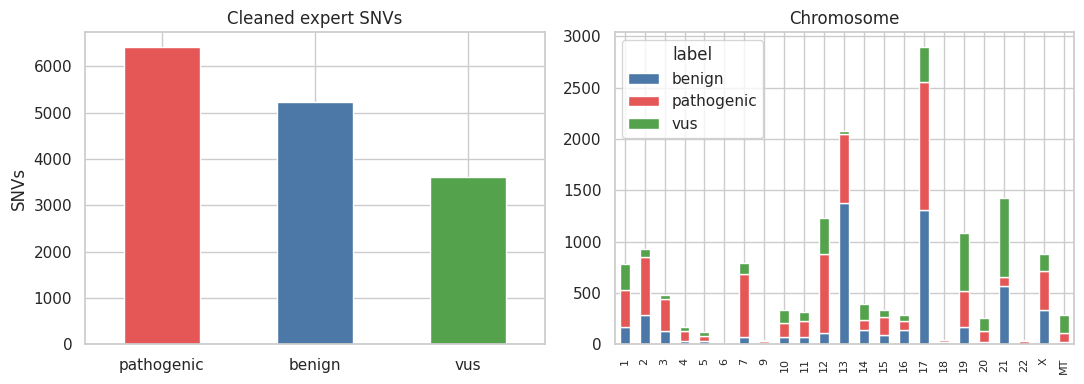

In [18]:
df_clean = pd.read_parquet(CLINVAR_CLEAN)
df_vus = pd.read_parquet(CLINVAR_CLEAN_VUS)
pb = pd.concat(
    [df_clean.assign(set="labelled P/B"), df_vus.assign(set="VUS")],
    ignore_index=True,
)
print("labelled", df_clean.shape, df_clean["label"].value_counts().to_dict())
print("VUS     ", df_vus.shape, "genes", df_vus["GeneSymbol"].astype(str).nunique())
print("labelled genes", df_clean["GeneSymbol"].astype(str).nunique())
print("gene overlap P/B ∩ VUS",
      len(set(df_clean.GeneSymbol.astype(str)) & set(df_vus.GeneSymbol.astype(str))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pb["label"].value_counts().reindex(["pathogenic", "benign", "vus"]).plot(
    kind="bar", ax=axes[0], color=["#e45756", "#4c78a8", "#54a24b"], rot=0,
)
axes[0].set_ylabel("SNVs")
axes[0].set_title("Cleaned expert SNVs")
axes[0].set_xlabel("")

chrom_order = [str(c) for c in list(range(1, 23)) + ["X", "Y", "MT"]
               if str(c) in set(pb["Chromosome"].astype(str))]
ct = pd.crosstab(pb["Chromosome"].astype(str), pb["label"]).reindex(chrom_order)
ct.plot(kind="bar", stacked=True, ax=axes[1],
        color={"pathogenic": "#e45756", "benign": "#4c78a8", "vus": "#54a24b"})
axes[1].set_title("Chromosome")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()


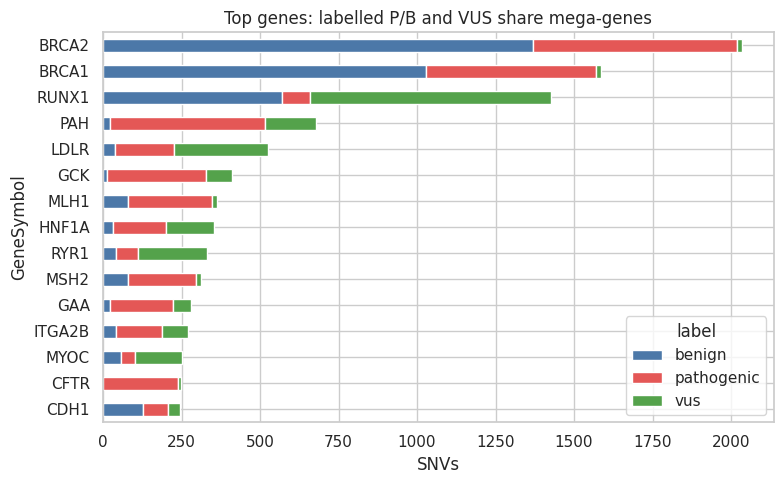

In [19]:
top = (
    pb.groupby(["GeneSymbol", "label"]).size().unstack(fill_value=0)
    .assign(n=lambda d: d.sum(axis=1))
    .sort_values("n", ascending=False)
    .head(15)
    .drop(columns="n")
)
fig, ax = plt.subplots(figsize=(8, 5))
top.plot(kind="barh", stacked=True, ax=ax,
         color={"pathogenic": "#e45756", "benign": "#4c78a8", "vus": "#54a24b"})
ax.invert_yaxis()
ax.set_xlabel("SNVs")
ax.set_title("Top genes: labelled P/B and VUS share mega-genes")
plt.tight_layout()
plt.show()
